In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)

import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [1]:
df = pd.read_csv('/Users/maria/Desktop/Code/HSE/MACRO/дз_2/data - Лист1.csv')

NameError: name 'pd' is not defined

In [3]:
df.shape

(34, 23)

In [4]:
new_values = [
    19.36, 17.08, 15.96, 17.20, 20.81, 19.31, 13.13, 18.11,
    28.85, 24.71, 25.12, 28.78, 38.23, 54.68, 65.60, 72.65, 97.33, 61.58,
    79.81, 111.54, 112.01, 108.96, 99.35, 53.02, 45.08, 54.89, 71.61, 64.20,
    43.33, 70.83, 98.99, 82.32, 79.91, 71.00
]

df["Oil Prices"] = new_values

In [5]:
df = df.drop(columns=["Import"])

In [6]:
df

,Year,Gross National Savings,Government Debt,Natural Gas Production,Iron Ore Production,Inbound Foreign Direct Investment,Natural Population Growth,Government Budget Revenues,Coal Imports,Share of Military Expenditures in the Budget,Foreign Reserves,GDP Growth,Average Annual Exchange Rate to USD,"Fuel Exports, % of Merchandise Exports",Coal Exports,Electricity Exports,OIL Production,Oil Prices,Fiscal Rule,Expenditure,Consumer Price Inflation,Politic leader
0,1992,36673.91,15.84,5.75,17671000.0,100.00,203480.54,26573.71,70262.00,4.27,18604.72,-5.30,207.42,60.61,24994401.00,15.45,444.00,19.36,0.0,21.97,8.66,0
1,1993,36673.91,15.84,4.74,13128900.0,1271.40,203480.54,26573.71,72918.00,4.27,711.00,-9.20,207.42,60.61,22651499.00,12.00,408.00,17.08,0.0,21.97,8.66,0
2,1994,36673.91,15.84,3.18,10520000.0,659.70,203480.54,2637.00,80441.00,4.27,1216.00,-12.60,35.54,60.61,26181682.00,5.50,415.00,15.96,0.0,21.97,8.66,0
3,1995,3038.00,15.84,4.19,14902200.0,964.26,203480.54,2806.00,95686.00,4.27,1660.00,-8.20,60.95,24.99,20969975.00,2.50,414.00,17.20,0.0,21.97,8.66,0
4,1996,4008.00,15.84,4.63,12975100.0,1136.88,203480.54,2781.00,42208.00,4.27,1960.00,0.50,67.30,32.94,21071975.00,1.73,457.00,20.81,0.0,21.97,8.66,0
5,1997,3560.00,15.84,5.75,13132600.0,1321.91,203480.54,2986.00,59005.00,4.27,2223.00,1.70,75.44,34.16,25079970.00,0.00,521.00,19.31,0.0,21.97,8.66,0
6,1998,3354.00,15.84,5.63,9335800.0,1160.89,203480.54,4026.00,90091.00,4.27,1965.00,-1.90,78.30,36.70,23402972.00,0.13,526.00,13.13,0.0,21.97,8.66,0
7,1999,2313.00,15.84,7.15,9616700.0,1437.69,203480.54,2959.00,121177.00,4.27,2001.00,2.70,119.52,43.64,17097980.00,0.08,604.00,18.11,0.0,21.97,8.66,0
8,2000,3873.00,15.84,8.18,16156800.0,1282.52,72276.00,3998.00,228311.00,4.27,2099.00,9.80,142.13,50.12,26238193.00,0.08,718.00,28.85,0.0,22.92,13.15,0
9,2001,5496.00,15.84,8.23,15886300.0,2835.00,73611.00,5683.00,207326.00,4.27,2506.00,13.50,146.74,56.07,29366459.00,1.64,815.00,24.71,0.0,23.38,8.37,0


In [7]:
df.columns.tolist()

['Year',
 'Gross National Savings',
 'Government Debt',
 'Natural Gas Production',
 'Iron Ore Production',
 'Inbound Foreign Direct Investment',
 'Natural Population Growth',
 'Government Budget Revenues',
 'Coal Imports',
 'Share of Military Expenditures in the Budget',
 'Foreign Reserves',
 'GDP Growth',
 'Average Annual Exchange Rate to USD',
 'Fuel Exports, % of Merchandise Exports',
 'Coal Exports',
 'Electricity Exports',
 'OIL Production',
 'Oil Prices',
 'Fiscal Rule',
 'Expenditure',
 'Consumer Price Inflation',
 'Politic leader']

In [8]:
df.isna().mean() * 100

Year                                            0.0
Gross National Savings                          0.0
Government Debt                                 0.0
Natural Gas Production                          0.0
Iron Ore Production                             0.0
Inbound Foreign Direct Investment               0.0
Natural Population Growth                       0.0
Government Budget Revenues                      0.0
Coal Imports                                    0.0
Share of Military Expenditures in the Budget    0.0
Foreign Reserves                                0.0
GDP Growth                                      0.0
Average Annual Exchange Rate to USD             0.0
Fuel Exports, % of Merchandise Exports          0.0
Coal Exports                                    0.0
Electricity Exports                             0.0
OIL Production                                  0.0
Oil Prices                                      0.0
Fiscal Rule                                     0.0
Expenditure 

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 22 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Year                                          34 non-null     int64  
 1   Gross National Savings                        34 non-null     float64
 2   Government Debt                               34 non-null     float64
 3   Natural Gas Production                        34 non-null     float64
 4   Iron Ore Production                           34 non-null     float64
 5   Inbound Foreign Direct Investment             34 non-null     float64
 6   Natural Population Growth                     34 non-null     float64
 7   Government Budget Revenues                    34 non-null     float64
 8   Coal Imports                                  34 non-null     float64
 9   Share of Military Expenditures in the Budget  34 non-null     float

In [10]:
df = df.rename(columns={"Year": "Date"})

## 2. рост ВВП

### 5. Выберите зависимую переменную для эконометрического исследования. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранной переменной, опишите ее. Приведите ссылку на статистический источник.

In [11]:
df["GDP Growth"].describe().round(3)

count    34.000
mean      3.427
std       5.887
min     -12.600
25%       1.200
50%       4.150
75%       7.375
max      13.500
Name: GDP Growth, dtype: float64

Text(0.5, 1.0, 'Dynamics of GDP Growth in Kazakhstan')

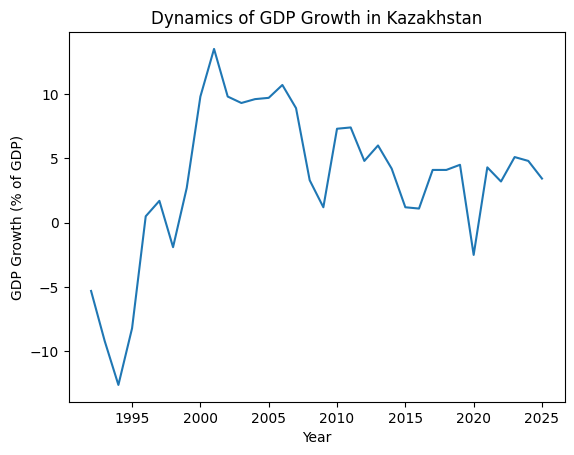

In [12]:
plt.figure()
plt.plot(df["Date"], df["GDP Growth"])
plt.xlabel("Year")
plt.ylabel("GDP Growth (% of GDP)")
plt.title("Dynamics of GDP Growth in Kazakhstan")

### 6. Выберите объясняющую переменную, отвечающую за работу фискального правила. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранной переменной, опишите ее. Приведите ссылку на статистический источник.

In [13]:
df["Oil Prices"].describe().round(3)

count     34.000
mean      55.451
std       31.757
min       13.130
25%       24.812
50%       54.785
75%       78.020
max      112.010
Name: Oil Prices, dtype: float64

Text(0.5, 1.0, 'Dynamics of Oil Prices in Kazakhstan')

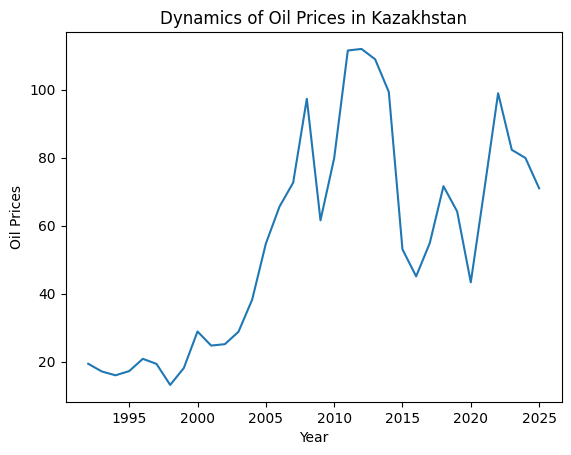

In [14]:
plt.figure()
plt.plot(df["Date"], df["Oil Prices"])
plt.xlabel("Year")
plt.ylabel("Oil Prices")
plt.title("Dynamics of Oil Prices in Kazakhstan")

### 7. Выберите контрольные переменные для Вашего исследования. Обоснуйте свой выбор. На отдельном графике представьте динамику выбранных переменных, опишите ее. Приведите ссылки на статистические источники.

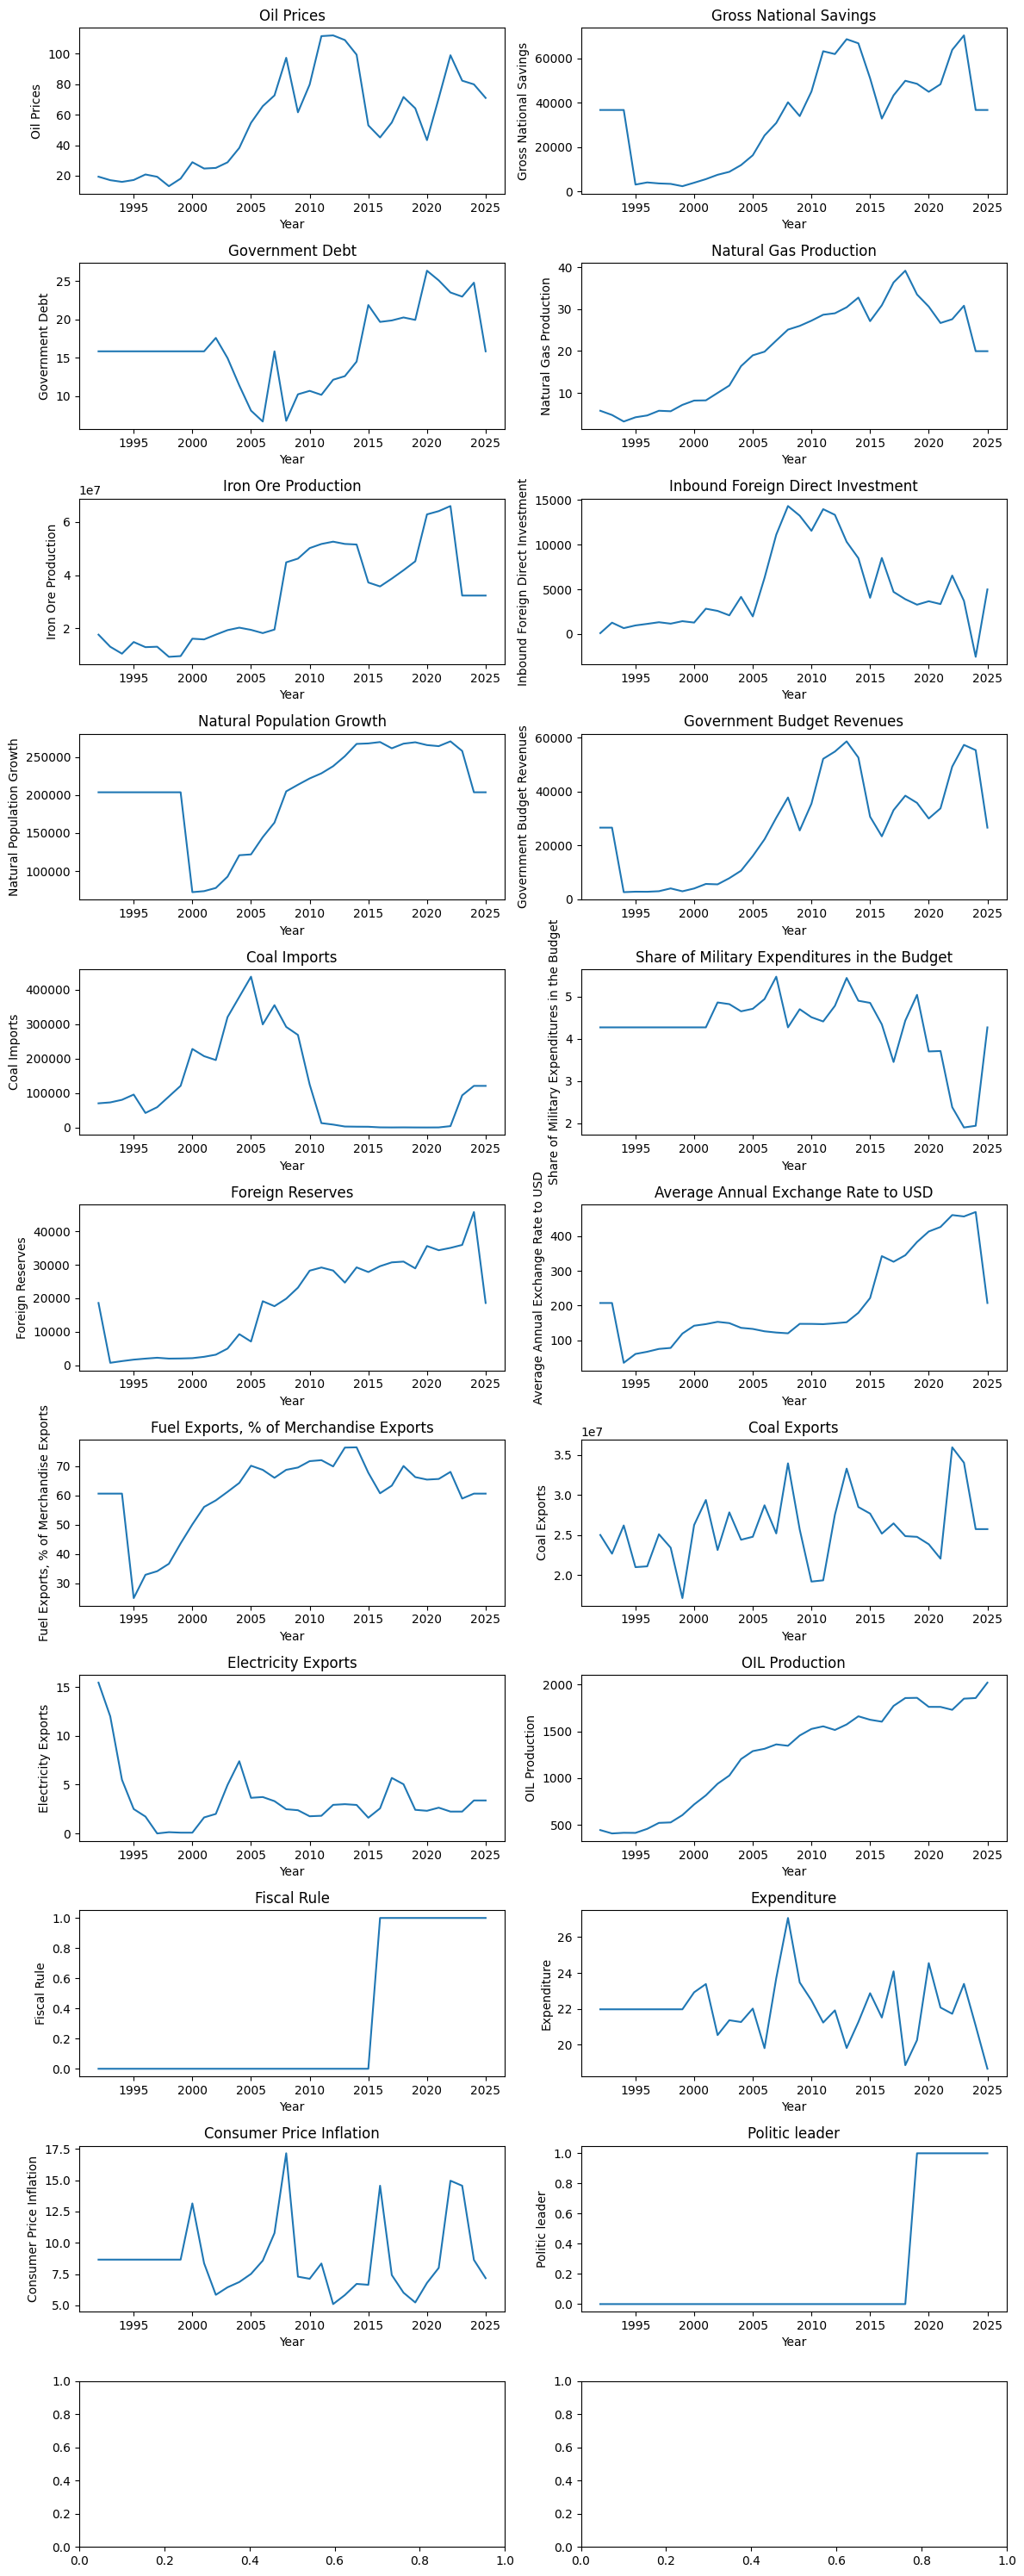

In [15]:
vars_to_plot = [
    'Oil Prices',                 # контрольная
    'Gross National Savings',
    'Government Debt',
    'Natural Gas Production',
    'Iron Ore Production',
    'Inbound Foreign Direct Investment',
    'Natural Population Growth',
    'Government Budget Revenues',
    'Coal Imports',
    'Share of Military Expenditures in the Budget',
    'Foreign Reserves',
    'Average Annual Exchange Rate to USD',
    'Fuel Exports, % of Merchandise Exports',
    'Coal Exports',
    'Electricity Exports',
    'OIL Production',
    'Fiscal Rule',
    'Expenditure',
    'Consumer Price Inflation',
    'Politic leader'
]

fig, axes = plt.subplots(11, 2, figsize=(12, 30))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    axes[i].plot(df["Date"], df[var])
    axes[i].set_title(var)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel(var)

plt.tight_layout()

### 8. Если Вы используете дамми-переменную в своем исследовании, опишите и обоснуйте.

### 9. Выпишите уравнение спецификации, которое Вы будете оценивать. В таблице опишите все основные описательные статистики выбранных переменных.

In [59]:
cols = df.columns
mid = len(cols) // 2

first_half = cols[:mid]
second_half = cols[mid:]

display(df[first_half].describe().round(2))

display(df[second_half].describe().round(2))


,Date,Gross National Savings,Government Debt,Natural Gas Production,Iron Ore Production,Inbound Foreign Direct Investment,Natural Population Growth,Government Budget Revenues,Coal Imports,Share of Military Expenditures in the Budget,Foreign Reserves
count,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00
mean,2008.50,33569.52,16.18,19.97,31936761.76,4994.21,203480.54,26573.71,120972.59,4.27,18604.72
std,9.96,22108.82,5.08,11.16,17705090.54,4545.76,61390.31,18631.01,129956.72,0.82,13623.14
min,1992.00,2313.00,6.68,3.18,9335800.00,-2550.49,72276.00,2637.00,21.00,1.90,711.00
25%,2000.25,9553.25,13.08,8.19,16535350.00,1350.86,203480.54,6216.50,3113.50,4.27,2664.75
50%,2008.50,36673.91,15.84,21.24,32363100.00,3691.76,203480.54,26573.71,85266.00,4.27,19505.00
75%,2016.75,48426.50,19.82,28.93,45991475.00,8002.58,260375.25,37255.25,204502.50,4.76,29241.25
max,2025.00,70302.00,26.36,39.18,66000000.00,14321.76,270370.00,58577.00,438410.00,5.47,45808.00


,GDP Growth,Average Annual Exchange Rate to USD,"Fuel Exports, % of Merchandise Exports",Coal Exports,Electricity Exports,OIL Production,Oil Prices,Fiscal Rule,Expenditure,Consumer Price Inflation,Politic leader
count,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00
mean,3.43,207.42,60.61,25723621.19,3.38,1257.72,55.45,0.29,21.97,8.66,0.21
std,5.89,128.28,12.54,4220621.13,3.11,533.55,31.76,0.46,1.62,2.93,0.41
min,-12.60,35.54,24.99,17097980.00,0.00,408.00,13.13,0.00,18.65,5.11,0.00
25%,1.20,127.79,59.35,23510567.50,1.86,742.25,24.81,0.00,21.26,6.82,0.00
50%,4.15,149.35,63.80,25170530.50,2.54,1407.50,54.78,0.00,21.97,8.36,0.00
75%,7.38,299.93,68.72,27631718.00,3.58,1712.07,78.02,1.00,22.77,8.66,0.00
max,13.50,468.96,76.39,35948140.00,15.45,2019.86,112.01,1.00,27.07,17.15,1.00


In [16]:
df.describe().round(2)

,Date,Gross National Savings,Government Debt,Natural Gas Production,Iron Ore Production,Inbound Foreign Direct Investment,Natural Population Growth,Government Budget Revenues,Coal Imports,Share of Military Expenditures in the Budget,Foreign Reserves,GDP Growth,Average Annual Exchange Rate to USD,"Fuel Exports, % of Merchandise Exports",Coal Exports,Electricity Exports,OIL Production,Oil Prices,Fiscal Rule,Expenditure,Consumer Price Inflation,Politic leader
count,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00,34.00
mean,2008.50,33569.52,16.18,19.97,31936761.76,4994.21,203480.54,26573.71,120972.59,4.27,18604.72,3.43,207.42,60.61,25723621.19,3.38,1257.72,55.45,0.29,21.97,8.66,0.21
std,9.96,22108.82,5.08,11.16,17705090.54,4545.76,61390.31,18631.01,129956.72,0.82,13623.14,5.89,128.28,12.54,4220621.13,3.11,533.55,31.76,0.46,1.62,2.93,0.41
min,1992.00,2313.00,6.68,3.18,9335800.00,-2550.49,72276.00,2637.00,21.00,1.90,711.00,-12.60,35.54,24.99,17097980.00,0.00,408.00,13.13,0.00,18.65,5.11,0.00
25%,2000.25,9553.25,13.08,8.19,16535350.00,1350.86,203480.54,6216.50,3113.50,4.27,2664.75,1.20,127.79,59.35,23510567.50,1.86,742.25,24.81,0.00,21.26,6.82,0.00
50%,2008.50,36673.91,15.84,21.24,32363100.00,3691.76,203480.54,26573.71,85266.00,4.27,19505.00,4.15,149.35,63.80,25170530.50,2.54,1407.50,54.78,0.00,21.97,8.36,0.00
75%,2016.75,48426.50,19.82,28.93,45991475.00,8002.58,260375.25,37255.25,204502.50,4.76,29241.25,7.38,299.93,68.72,27631718.00,3.58,1712.07,78.02,1.00,22.77,8.66,0.00
max,2025.00,70302.00,26.36,39.18,66000000.00,14321.76,270370.00,58577.00,438410.00,5.47,45808.00,13.50,468.96,76.39,35948140.00,15.45,2019.86,112.01,1.00,27.07,17.15,1.00


### 10.  Используя МНК, эмпирически оцените коэффициенты Вашей модели. Результаты оценки представьте в тексте в адекватном и аккуратном виде. Вы обязаны скопировать результаты из используемой программы в Приложение! Без этого работа оценивается как 0. Проинтерпретируйте полученные результаты.

 # Как варик брать не все-все переменные, а с самой большой корреляцыей по модулю

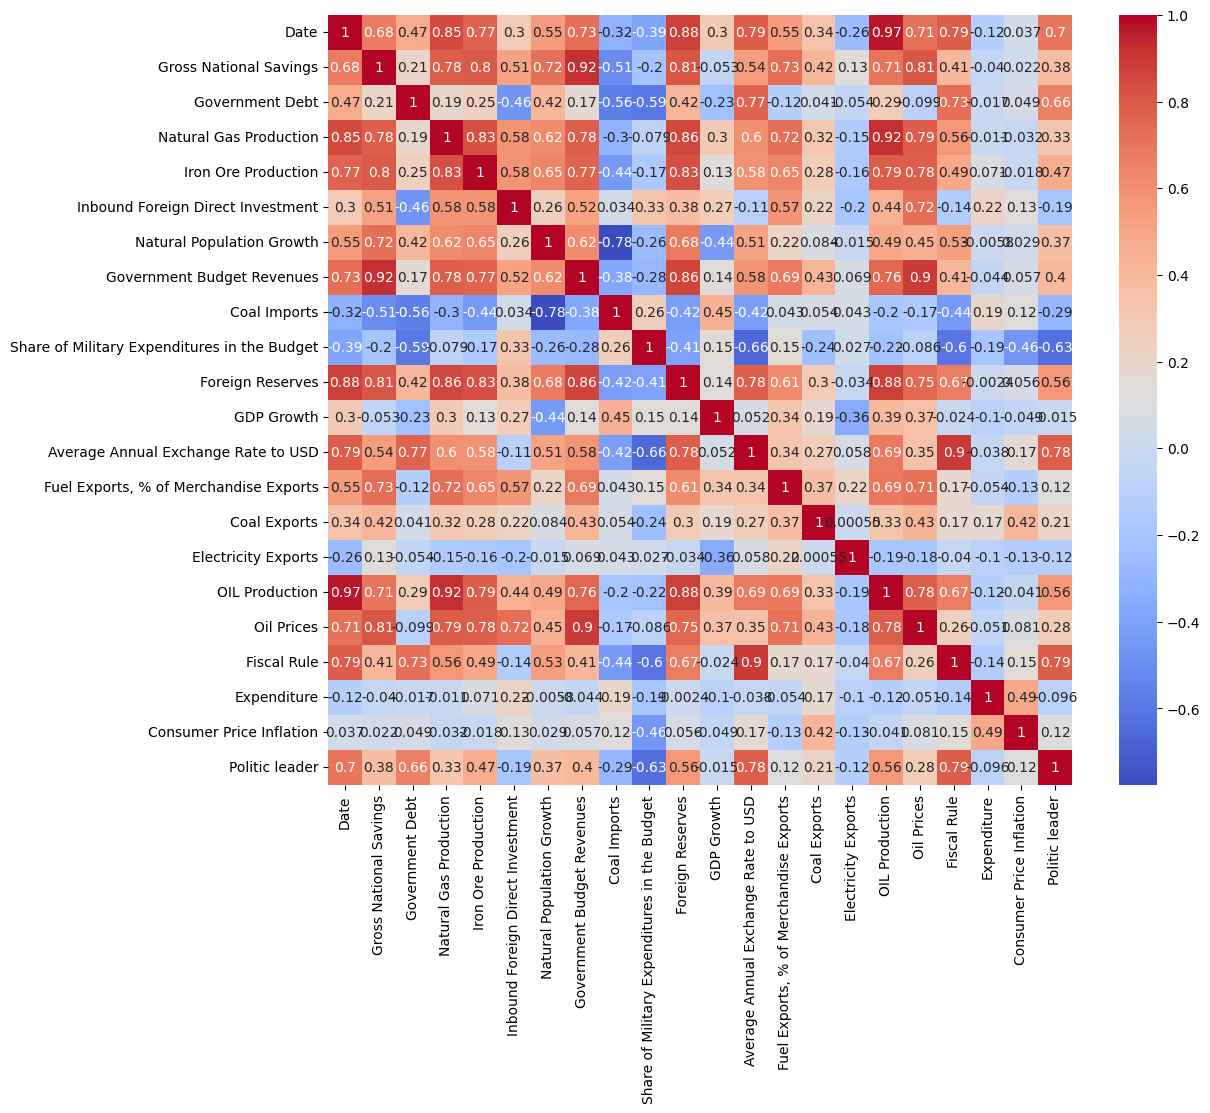

In [17]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [35]:
y = df["GDP Growth"]  # ВВП — зависимая

X = df[[
    
    "Gross National Savings",
    "Government Debt",
    "Natural Gas Production",
    "Iron Ore Production",
    "Inbound Foreign Direct Investment",
    "Natural Population Growth",
    "Government Budget Revenues",
    "Coal Imports",
    "Share of Military Expenditures in the Budget",
    "Foreign Reserves",
    "Average Annual Exchange Rate to USD",
    "Fuel Exports, % of Merchandise Exports",
    "Coal Exports",
    "Electricity Exports",
    "OIL Production",
    "Oil Prices",          # контрольная
    "Fiscal Rule",
    "Expenditure",
    "Consumer Price Inflation",
    "Politic leader"
]]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             GDP Growth   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.801
Method:                 Least Squares   F-statistic:                     7.627
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           0.000267
Time:                        14:18:52   Log-Likelihood:                -64.755
No. Observations:                  34   AIC:                             171.5
Df Residuals:                      13   BIC:                             203.6
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
================================================================================================================
                                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------
const                                           14.0828     17.102      0.823      0.425     -22.864      51.030
Gross National Savings                          -0.0004      0.000     -1.828      0.091      -0.001    6.51e-05
Government Debt                                  0.1170      0.360      0.325      0.750      -0.661       0.895
Natural Gas Production                           0.9006      0.461      1.954      0.073      -0.095       1.896
Iron Ore Production                          -2.976e-07   1.18e-07     -2.519      0.026   -5.53e-07   -4.23e-08
Inbound Foreign Direct Investment                0.0003      0.000      0.981      0.344      -0.000       0.001
Natural Population Growth                    -7.402e-05   2.31e-05     -3.204      0.007      -0.000   -2.41e-05
Government Budget Revenues                      -0.0003      0.000     -1.465      0.167      -0.001       0.000
Coal Imports                                 -3.978e-05   1.53e-05     -2.595      0.022   -7.29e-05   -6.66e-06
Share of Military Expenditures in the Budget    -2.0920      2.081     -1.005      0.333      -6.587       2.403
Foreign Reserves                                -0.0001      0.000     -0.677      0.510      -0.000       0.000
Average Annual Exchange Rate to USD              0.0370      0.032      1.143      0.274      -0.033       0.107
Fuel Exports, % of Merchandise Exports           0.1287      0.187      0.690      0.502      -0.274       0.532
Coal Exports                                  4.475e-08    1.6e-07      0.279      0.784   -3.02e-07    3.91e-07
Electricity Exports                              0.5057      0.439      1.153      0.270      -0.442       1.454
OIL Production                                   0.0012      0.006      0.193      0.850      -0.012       0.014
Oil Prices                                       0.2754      0.114      2.409      0.032       0.028       0.522
Fiscal Rule                                    -18.0652      6.394     -2.826      0.014     -31.878      -4.253
Expenditure                                     -0.1749      0.635     -0.275      0.787      -1.547       1.198
Consumer Price Inflation                         0.0057      0.418      0.014      0.989      -0.896       0.908
Politic leader                                  10.0160      6.867      1.459      0.168      -4.819      24.851
==============================================================================
Omnibus:                        2.556   Durbin-Watson:                   2.543
Prob(Omnibus):                  0.279   Jarque-Bera (JB):                1.602
Skew:                           0.279   Prob(JB):                        0.449
Kurtosis:                       2.095   Cond. No.      

In [51]:
y = df["GDP Growth"]

X = df[[
    "Iron Ore Production",
    "Natural Population Growth",
    "Coal Imports",
    "Oil Prices",
    "Fiscal Rule",
    "Gross National Savings",
    "Natural Gas Production"
]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             GDP Growth   R-squared:                       0.839
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     19.33
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           8.30e-09
Time:                        22:24:39   Log-Likelihood:                -76.980
No. Observations:                  34   AIC:                             170.0
Df Residuals:                      26   BIC:                             182.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        15.8522      3.301      4.802      0.000       9.066      22.638
Iron Ore Production       -4.948e-08   5.66e-08     -0.875      0.390   -1.66e-07    6.68e-08
Natural Population Growth -9.837e-05   1.62e-05     -6.076      0.000      -0.000   -6.51e-05
Coal Imports              -1.477e-05   6.58e-06     -2.244      0.034   -2.83e-05   -1.24e-06
Oil Prices                    0.1256      0.034      3.644      0.001       0.055       0.196
Fiscal Rule                   0.2956      1.378      0.215      0.832      -2.536       3.127
Gross National Savings       -0.0002   5.07e-05     -3.198      0.004      -0.000    -5.8e-05
Natural Gas Production        0.4684      0.098      4.769      0.000       0.267       0.670
==============================================================================
Omnibus:                        0.662   Durbin-Watson:                   1.828
Prob(Omnibus):                  0.718   Jarque-Bera (JB):                0.758
Skew:                          -0.234   Prob(JB):                        0.684
Kurtosis:                       2.438   Cond. No.                     2.63e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.63e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

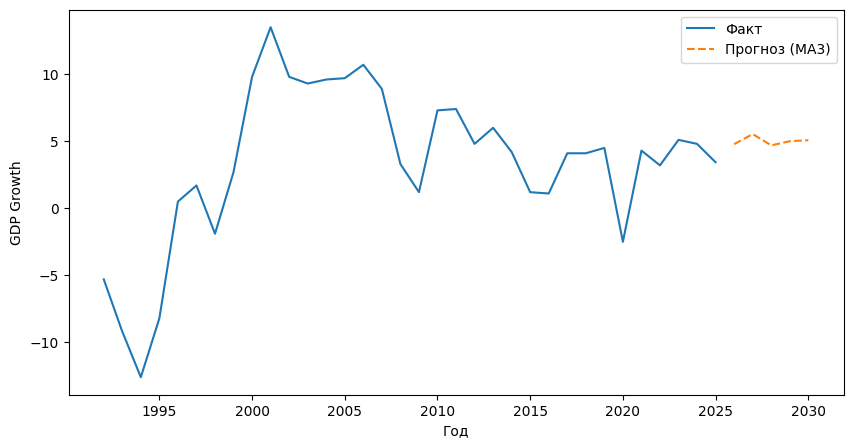

In [ ]:
X_vars = [
   
    'Gross National Savings',
    'Government Debt',
    'Natural Gas Production',
    'Iron Ore Production',
    'Inbound Foreign Direct Investment',
    'Natural Population Growth',
    'Government Budget Revenues',
    'Coal Imports',
    'Share of Military Expenditures in the Budget',
    'Foreign Reserves',
    'Average Annual Exchange Rate to USD',
    'Fuel Exports, % of Merchandise Exports',
    'Coal Exports',
    'Electricity Exports',
    'OIL Production',
    'Oil Prices',          
    'Expenditure',
    'Consumer Price Inflation',
    'Politic leader',
    'Fiscal Rule'
]

future_years = [2026, 2027, 2028, 2029, 2030]

X_extended = df[X_vars].copy()

for year in future_years:
    ma3 = X_extended.tail(3).mean()
    X_extended.loc[year] = ma3

X_future = X_extended.loc[future_years].copy()
X_future["const"] = 1
X_future = X_future[model.model.exog_names]

forecast_ma = model.predict(X_future)

plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["GDP Growth"], label="Факт")
plt.plot(forecast_ma.index, forecast_ma.values, label="Прогноз (MA3)", linestyle="--")
plt.xlabel("Год")
plt.ylabel("GDP Growth")
plt.legend()
plt.show()

Gross_National_Savings, Gov_Debt, Natural_Gas_Production, Iron_Ore_Production, FDI_Inbound, Natural_Pop_Growth, Gov_Budget_Revenues, Coal_Imports, Military_Share, Foreign_Reserves, FX_Rate_USD, Fuel_Exports, Coal_Exports, Electricity_Exports, Oil_Production, Oil_Prices, Fiscal_Rule, Expenditure, CPI_Inflation, Politic_Leader

In [19]:
model.params.round(5)

const                                           14.08282
Gross National Savings                          -0.00036
Government Debt                                  0.11700
Natural Gas Production                           0.90058
Iron Ore Production                             -0.00000
Inbound Foreign Direct Investment                0.00033
Natural Population Growth                       -0.00007
Government Budget Revenues                      -0.00030
Coal Imports                                    -0.00004
Share of Military Expenditures in the Budget    -2.09200
Foreign Reserves                                -0.00010
Average Annual Exchange Rate to USD              0.03700
Fuel Exports, % of Merchandise Exports           0.12868
Coal Exports                                     0.00000
Electricity Exports                              0.50575
OIL Production                                   0.00117
Oil Prices                                       0.27542
Fiscal Rule                    

In [52]:
p = model.pvalues

significant = [var for var in p.index if p[var] < 0.10]
nonsignificant = [var for var in p.index if p[var] >= 0.10]

print("Значимые переменные:", significant)
print("Незначимые переменные:", nonsignificant)


Значимые переменные: ['const', 'Natural Population Growth', 'Coal Imports', 'Oil Prices', 'Gross National Savings', 'Natural Gas Production']
Незначимые переменные: ['Iron Ore Production', 'Fiscal Rule']


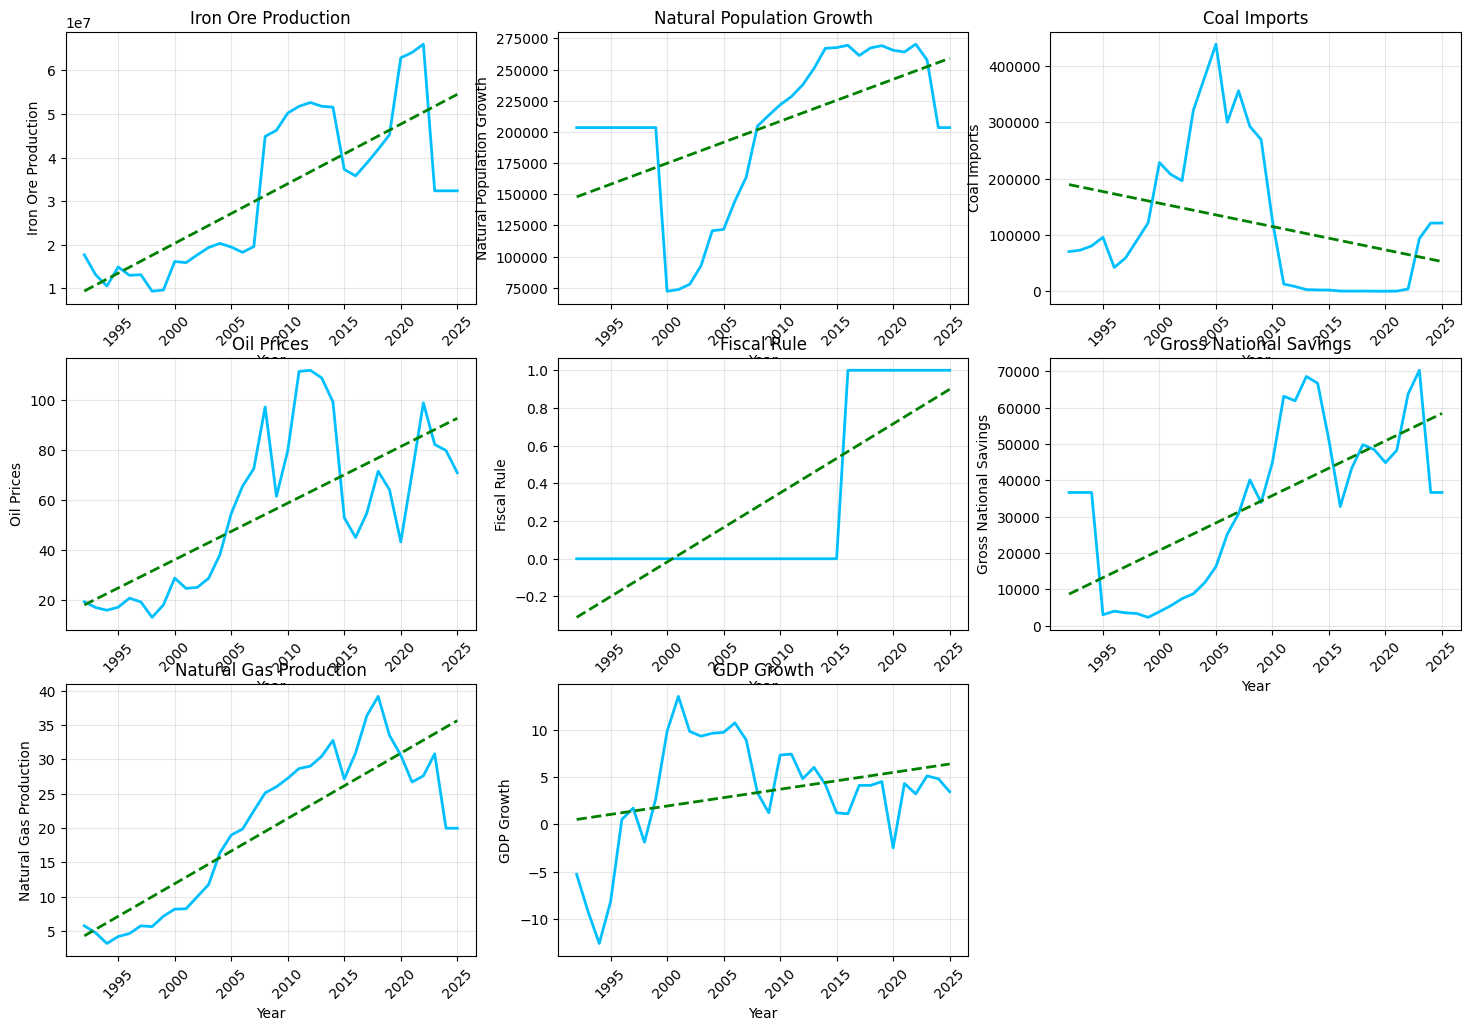

In [21]:
import matplotlib.pyplot as plt
import numpy as np

cols = [
    "Iron Ore Production", "Natural Population Growth", "Coal Imports",
    "Oil Prices", "Fiscal Rule", "Gross National Savings",
    "Natural Gas Production", "GDP Growth"
]


plt.figure(figsize=(18, 12))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    
    x = df["Date"]
    y = df[col]

    # Основная линия
    plt.plot(x, y, color="deepskyblue", linewidth=2, label=col)

    # Линия тренда
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x), color="green", linewidth=2, linestyle="--", label="Trend")

    plt.grid(alpha=0.3)
    plt.title(col)
    plt.xlabel("Year")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.legend


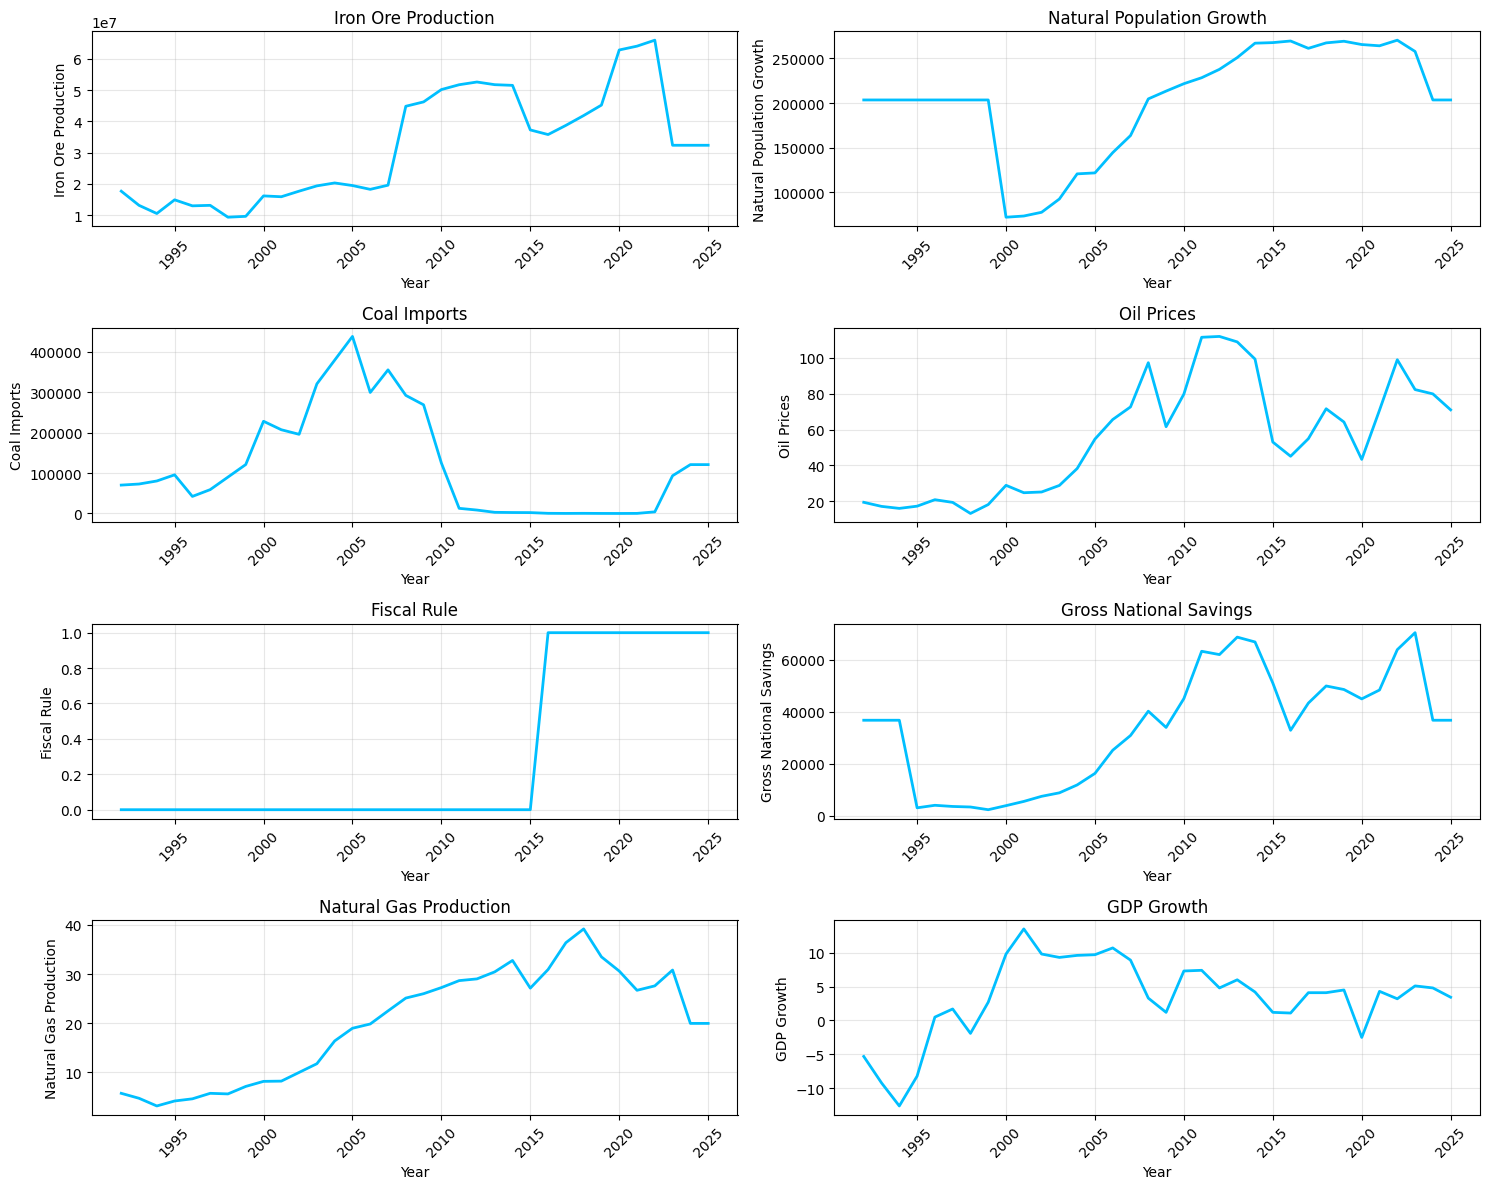

In [41]:
import matplotlib.pyplot as plt

cols = [
    "Iron Ore Production", "Natural Population Growth", "Coal Imports",
    "Oil Prices", "Fiscal Rule", "Gross National Savings",
    "Natural Gas Production", "GDP Growth"
]

plt.figure(figsize=(15, 12))

for i, col in enumerate(cols, 1):
    plt.subplot(4, 2, i)
    plt.plot(df["Date"], df[col], color="deepskyblue", linewidth=2)
    plt.grid(alpha=0.3)
    plt.title(col)
    plt.xlabel("Year")
    plt.ylabel(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


также, построим 95% доверительные интервалы для всех коэффициентов:

In [53]:
conf = model.conf_int(alpha=0.05)

significant_ci = []
nonsignificant_ci = []

for var in conf.index:
    low, high = conf.loc[var]
    if low > 0 or high < 0:      # интервал не содержит ноль
        significant_ci.append(var)
    else:
        nonsignificant_ci.append(var)

print("Значимые по доверительным интервалам:", significant_ci)
print("Незначимые по доверительным интервалам:", nonsignificant_ci)

Значимые по доверительным интервалам: ['const', 'Natural Population Growth', 'Coal Imports', 'Oil Prices', 'Gross National Savings', 'Natural Gas Production']
Незначимые по доверительным интервалам: ['Iron Ore Production', 'Fiscal Rule']


### 11.  Проведите проверку результатов на устойчивость. Метод Вы выбираете сами. Устойчивы ли Ваши результаты?

#### 1 способ: Робастные стандартные ошибки (HC3)

In [54]:
model_robust = model.get_robustcov_results(cov_type="HC3")

p = model_robust.pvalues
names = model_robust.model.exog_names

significant = [names[i] for i in range(len(p)) if p[i] < 0.10]
nonsignificant = [names[i] for i in range(len(p)) if p[i] >= 0.10]

print("Значимые (robust):", significant)
print("Незначимые (robust):", nonsignificant)

Значимые (robust): ['const', 'Natural Population Growth', 'Coal Imports', 'Oil Prices', 'Gross National Savings', 'Natural Gas Production']
Незначимые (robust): ['Iron Ore Production', 'Fiscal Rule']


In [55]:
model_robust = model.get_robustcov_results(cov_type="HC2")

p = model_robust.pvalues
names = model_robust.model.exog_names

significant = [names[i] for i in range(len(p)) if p[i] < 0.10]
nonsignificant = [names[i] for i in range(len(p)) if p[i] >= 0.10]

print("Значимые (robust):", significant)
print("Незначимые (robust):", nonsignificant)


Значимые (robust): ['const', 'Natural Population Growth', 'Coal Imports', 'Oil Prices', 'Gross National Savings', 'Natural Gas Production']
Незначимые (robust): ['Iron Ore Production', 'Fiscal Rule']


In [56]:
model_robust = model.get_robustcov_results(cov_type="HC1")

p = model_robust.pvalues
names = model_robust.model.exog_names

significant = [names[i] for i in range(len(p)) if p[i] < 0.10]
nonsignificant = [names[i] for i in range(len(p)) if p[i] >= 0.10]

print("Значимые (robust):", significant)
print("Незначимые (robust):", nonsignificant)


Значимые (robust): ['const', 'Natural Population Growth', 'Coal Imports', 'Oil Prices', 'Gross National Savings', 'Natural Gas Production']
Незначимые (robust): ['Iron Ore Production', 'Fiscal Rule']


In [57]:
# HAC (Newey–West)
model_hac = model.get_robustcov_results(cov_type="HAC", maxlags=1)

p = model_hac.pvalues
names = model_hac.model.exog_names

significant_hac = [names[i] for i in range(len(p)) if p[i] < 0.10]
nonsignificant_hac = [names[i] for i in range(len(p)) if p[i] >= 0.10]

print("Значимые (HAC):", significant_hac)
print("Незначимые (HAC):", nonsignificant_hac)


# HC3 (для сравнения)
model_hc3 = model.get_robustcov_results(cov_type="HC2")

p3 = model_hc3.pvalues
names3 = model_hc3.model.exog_names

significant_hc3 = [names3[i] for i in range(len(p3)) if p3[i] < 0.10]
nonsignificant_hc3 = [names3[i] for i in range(len(p3)) if p3[i] >= 0.10]

print("\nЗначимые (HC3):", significant_hc3)
print("Незначимые (HC3):", nonsignificant_hc3)


Значимые (HAC): ['const', 'Natural Population Growth', 'Coal Imports', 'Oil Prices', 'Gross National Savings', 'Natural Gas Production']
Незначимые (HAC): ['Iron Ore Production', 'Fiscal Rule']

Значимые (HC3): ['const', 'Natural Population Growth', 'Coal Imports', 'Oil Prices', 'Gross National Savings', 'Natural Gas Production']
Незначимые (HC3): ['Iron Ore Production', 'Fiscal Rule']


#### 2 способ: Мультиколлинеарность (VIF)

In [58]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data

,Variable,VIF
0,const,52.272868
1,Iron Ore Production,4.667614
2,Natural Population Growth,4.597870
3,Coal Imports,3.405324
4,Oil Prices,5.572332
5,Fiscal Rule,1.889556
6,Gross National Savings,5.852262
7,Natural Gas Production,5.595155


#### 3 способ: оценка модели на части признаков. (Leave-one-out robustness check)

Мы проверяем, насколько чувствительны результаты модели к выбору набора регрессоров. Для этого по очереди исключаем из модели каждую объясняющую переменную, заново оцениваем регрессию и смотрим, как изменяется коэффициент при ключевой переменной FiscalRule. Если коэффициент остаётся примерно таким же, значит модель устойчива к спецификации; если изменяется резко, значит зависимость чувствительна к исключению этой переменной.

Этот метод широко используется как тест устойчивости результатов (robustness to model specification).

In [26]:
y = df["GDP Growth"]

control_vars = [

    'Gross National Savings',
    'Government Debt',
    'Natural Gas Production',
    'Iron Ore Production',
    'Inbound Foreign Direct Investment',
    'Natural Population Growth',
    'Government Budget Revenues',
    'Coal Imports',
    'Share of Military Expenditures in the Budget',
    'Foreign Reserves',
    'Average Annual Exchange Rate to USD',
    'Fuel Exports, % of Merchandise Exports',
    'Coal Exports',
    'Electricity Exports',
    'OIL Production',
    'Expenditure',
    'Consumer Price Inflation',
    'Politic leader'
]

results = []

for var in control_vars:
    vars_subset = [v for v in control_vars if v != var]
    model = sm.OLS(y, sm.add_constant(df[vars_subset + ["Oil Prices"]])).fit()
    coef = model.params.get("Oil Prices", None)
    results.append([var, coef])

pd.DataFrame(results, columns=["Removed variable", "OilPrices coefficient"])

,Removed variable,OilPrices coefficient
0,Gross National Savings,0.210763
1,Government Debt,0.196444
2,Natural Gas Production,0.213556
3,Iron Ore Production,0.113140
4,Inbound Foreign Direct Investment,0.202370
5,Natural Population Growth,0.307221
6,Government Budget Revenues,0.135159
7,Coal Imports,0.188492
8,Share of Military Expenditures in the Budget,0.177961
9,Foreign Reserves,0.202443


### 12.  Постройте прогноз, используя Вашу оцененную модель. Результаты представьте на графике. Опишите его и проинтерпретируйте.

прогноз по 3-летнему скользящему среднему (MA-3) и подстановка результата OLS-модель.

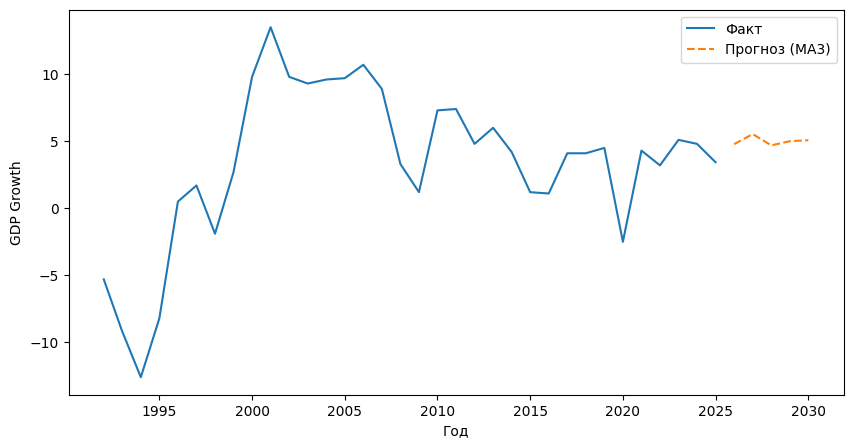

In [27]:
X_vars = [
   
    'Gross National Savings',
    'Government Debt',
    'Natural Gas Production',
    'Iron Ore Production',
    'Inbound Foreign Direct Investment',
    'Natural Population Growth',
    'Government Budget Revenues',
    'Coal Imports',
    'Share of Military Expenditures in the Budget',
    'Foreign Reserves',
    'Average Annual Exchange Rate to USD',
    'Fuel Exports, % of Merchandise Exports',
    'Coal Exports',
    'Electricity Exports',
    'OIL Production',
    'Oil Prices',          
    'Expenditure',
    'Consumer Price Inflation',
    'Politic leader',
    'Fiscal Rule'
]

future_years = [2026, 2027, 2028, 2029, 2030]

X_extended = df[X_vars].copy()

for year in future_years:
    ma3 = X_extended.tail(3).mean()
    X_extended.loc[year] = ma3

X_future = X_extended.loc[future_years].copy()
X_future["const"] = 1
X_future = X_future[model.model.exog_names]

forecast_ma = model.predict(X_future)

plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["GDP Growth"], label="Факт")
plt.plot(forecast_ma.index, forecast_ma.values, label="Прогноз (MA3)", linestyle="--")
plt.xlabel("Год")
plt.ylabel("GDP Growth")
plt.legend()
plt.show()

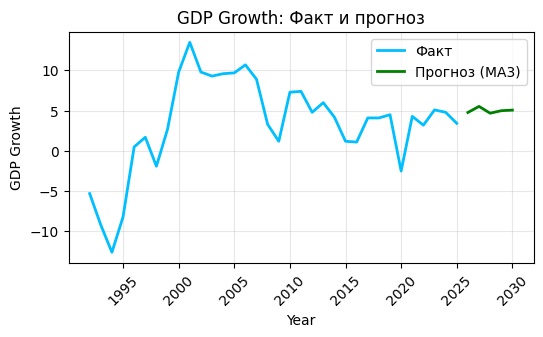

In [50]:
plt.figure(figsize=(6, 3))

x_fact = df["Date"]
y_fact = df["GDP Growth"]

# Факт: основная линия
plt.plot(
    x_fact, y_fact,
    color="deepskyblue", linewidth=2, label="Факт"
)

# Прогноз: основная линия
plt.plot(
    forecast_ma.index, forecast_ma.values,
    color="green", linewidth=2, label="Прогноз (MA3)"
)

plt.grid(alpha=0.3)
plt.title("GDP Growth: Факт и прогноз")
plt.xlabel("Year")
plt.ylabel("GDP Growth")
plt.xticks(rotation=45)
plt.legend()

plt.show()
